In [1]:
# Cell 2: Model Training and Saving (Run this once after Cell 1)

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
import os
import numpy as np
import joblib

# Note: This cell assumes you have already run Cell 1 and the data has been loaded and split.
try:
    X_train = np.load(os.path.join("../data", "X_train.npy"))
    y_train = np.load(os.path.join("../data", "y_train.npy"))
    X_test = np.load(os.path.join("../data", "X_test.npy"))
    y_test = np.load(os.path.join("../data", "y_test.npy"))
    X_train_scaled = np.load(os.path.join("../data", "X_train_scaled.npy"))
    X_test_scaled = np.load(os.path.join("../data", "X_test_scaled.npy"))
except FileNotFoundError:
    print("Data files not found. Please run Cell 1 to generate them first.")
    raise

os.makedirs("../models", exist_ok=True)
os.makedirs("../outputs", exist_ok=True)

# Define the individual classifiers
# Swapped KNN for HistGradientBoosting for 32k feature performance
clf1 = RandomForestClassifier(n_estimators=100, random_state=42)
clf2 = SVC(kernel="linear", probability=True, cache_size=2000, random_state=42)
clf3 = HistGradientBoostingClassifier(random_state=42)

classifiers = {
    "RandomForest": clf1,
    "SVM": clf2,
    "GradientBoosting": clf3,
}

# Train and save individual classifiers
for name, clf in classifiers.items():
    print(f"\nTraining {name}...")

    if name in ["SVM", "GradientBoosting"]:
        clf.fit(X_train_scaled, y_train)
        y_pred = clf.predict(X_test_scaled)
    else: # RandomForest doesn't require scaling for good performance
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

    print(f"\nClassification Report for {name}:\n")
    report = classification_report(y_test, y_pred)
    print(report)

    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix for {name}:\n{cm}\n")

    model_path = os.path.join("../models", f"{name.lower()}_model.pkl")
    joblib.dump(clf, model_path)
    print(f"Model saved to {model_path}")

    report_path = os.path.join("../outputs", f"{name.lower()}_report.txt")
    with open(report_path, "w") as f:
        f.write(f"Classification Report for {name}:\n{report}")
        f.write(f"\nConfusion Matrix:\n{np.array2string(cm)}\n")
    print(f"Report saved to {report_path}")

# --- Train and Save the VotingClassifier (Ensemble) ---
print("\nTraining and saving VotingClassifier...")
voting_clf = VotingClassifier(
    estimators=[('rf', clf1), ('svm', clf2), ('gb', clf3)],
    voting='soft'
)
voting_clf.fit(X_train_scaled, y_train)
y_pred_voting = voting_clf.predict(X_test_scaled)

print("\nClassification Report for VotingClassifier:\n")
report_voting = classification_report(y_test, y_pred_voting)
print(report_voting)
cm_voting = confusion_matrix(y_test, y_pred_voting)
print(f"Confusion Matrix for VotingClassifier:\n{cm_voting}\n")

model_path_voting = os.path.join("../models", "votingclassifier_model.pkl")
joblib.dump(voting_clf, model_path_voting)
print(f"Model saved to {model_path_voting}")

report_path_voting = os.path.join("../outputs", "votingclassifier_report.txt")
with open(report_path_voting, "w") as f:
    f.write(f"Classification Report for VotingClassifier:\n{report_voting}")
    f.write(f"\nConfusion Matrix:\n{np.array2string(cm_voting)}\n")
print(f"Report saved to {report_path_voting}")

print("\nTraining complete. Check the '../models' and '../outputs' folders for saved files.")


A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 6d6bbae143d832006294945121d1f1fc so we will re-download the data.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 72s 1us/step
Starting feature extraction...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 637ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step
1/1 ━━━━━━━━━━━━━━━

In [3]:
np.save(os.path.join("../data", "X_test.npy"), X_test)

In [4]:
# Cell 2: Model Training and Saving (Run this once after Cell 1)

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import os
import numpy as np
import joblib

# Note: This cell assumes you have already run Cell 1 and the data has been loaded and split.
try:
    X_train = np.load(os.path.join("../data", "X_train.npy"))
    y_train = np.load(os.path.join("../data", "y_train.npy"))
    X_test = np.load(os.path.join("../data", "X_test.npy"))
    y_test = np.load(os.path.join("../data", "y_test.npy"))
    X_train_scaled = np.load(os.path.join("../data", "X_train_scaled.npy"))
    X_test_scaled = np.load(os.path.join("../data", "X_test_scaled.npy"))
except FileNotFoundError:
    print("Data files not found. Please run Cell 1 to generate them first.")
    raise

os.makedirs("../models", exist_ok=True)
os.makedirs("../outputs", exist_ok=True)

# Define the individual classifiers
clf1 = RandomForestClassifier(n_estimators=100, random_state=42)
clf2 = SVC(kernel="linear", probability=True, random_state=42)
clf3 = KNeighborsClassifier(n_neighbors=5)

classifiers = {
    "RandomForest": clf1,
    "SVM": clf2,
    "KNN": clf3,
}

# Train and save individual classifiers
for name, clf in classifiers.items():
    print(f"\nTraining {name}...")
    
    if name in ["SVM", "KNN"]:
        clf.fit(X_train_scaled, y_train)
        y_pred = clf.predict(X_test_scaled)
    else: # RandomForest doesn't require scaling for good performance
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

    print(f"\nClassification Report for {name}:\n")
    report = classification_report(y_test, y_pred)
    print(report)

    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix for {name}:\n{cm}\n")

    model_path = os.path.join("../models", f"{name.lower()}_model.pkl")
    joblib.dump(clf, model_path)
    print(f"Model saved to {model_path}")

    report_path = os.path.join("../outputs", f"{name.lower()}_report.txt")
    with open(report_path, "w") as f:
        f.write(f"Classification Report for {name}:\n{report}")
        f.write(f"\nConfusion Matrix:\n{np.array2string(cm)}\n")
    print(f"Report saved to {report_path}")

# --- Train and Save the VotingClassifier ---
print("\nTraining and saving VotingClassifier...")
voting_clf = VotingClassifier(
    estimators=[('rf', clf1), ('svm', clf2), ('knn', clf3)],
    voting='soft'
)
voting_clf.fit(X_train_scaled, y_train)
y_pred_voting = voting_clf.predict(X_test_scaled)

print("\nClassification Report for VotingClassifier:\n")
report_voting = classification_report(y_test, y_pred_voting)
print(report_voting)
cm_voting = confusion_matrix(y_test, y_pred_voting)
print(f"Confusion Matrix for VotingClassifier:\n{cm_voting}\n")

model_path_voting = os.path.join("../models", "votingclassifier_model.pkl")
joblib.dump(voting_clf, model_path_voting)
print(f"Model saved to {model_path_voting}")

report_path_voting = os.path.join("../outputs", "votingclassifier_report.txt")
with open(report_path_voting, "w") as f:
    f.write(f"Classification Report for VotingClassifier:\n{report_voting}")
    f.write(f"\nConfusion Matrix:\n{np.array2string(cm_voting)}\n")
print(f"Report saved to {report_path_voting}")

print("\nTraining complete. Check the '../models' and '../outputs' folders for saved files.")


Training RandomForest...

Classification Report for RandomForest:

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       351
           1       0.56      0.26      0.36        68
           2       0.61      0.88      0.72       213
           3       0.40      0.11      0.17        36
           4       0.67      0.06      0.11        65

    accuracy                           0.76       733
   macro avg       0.63      0.46      0.46       733
weighted avg       0.74      0.76      0.71       733

Confusion Matrix for RandomForest:
[[343   3   5   0   0]
 [ 14  18  35   1   0]
 [ 14   7 187   4   1]
 [  2   2  27   4   1]
 [  5   2  53   1   4]]

Model saved to ../models\randomforest_model.pkl
Report saved to ../outputs\randomforest_report.txt

Training SVM...

Classification Report for SVM:

              precision    recall  f1-score   support

           0       0.93      0.98      0.95       351
           1       0.53      0.47


Starting visualization of existing models and reports...

Plotting Normalized Heatmap for RANDOMFOREST...


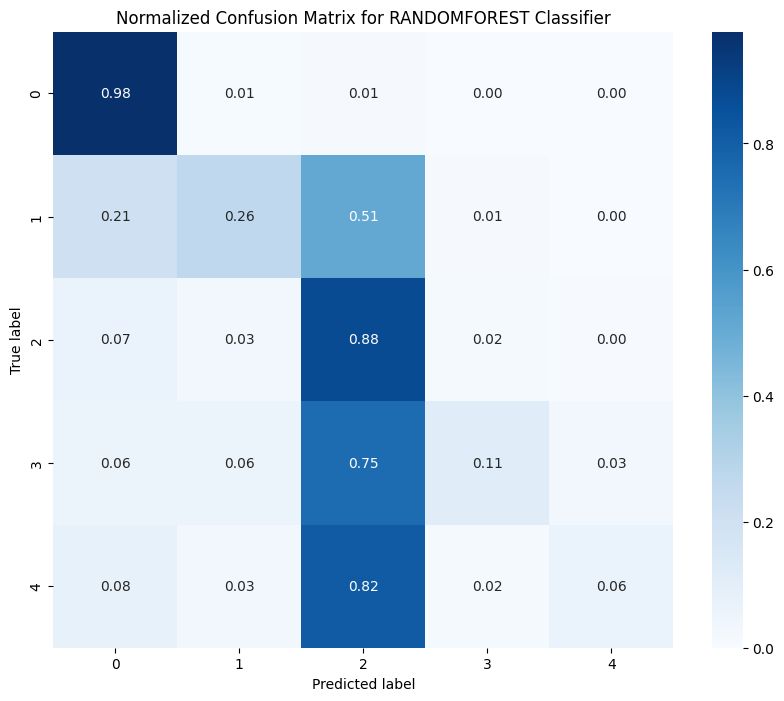

Plotting F1-Score Bar Chart for RANDOMFOREST...


d:\GitHub\final\scripts\visualize.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plt.ylim(0, 1.0)


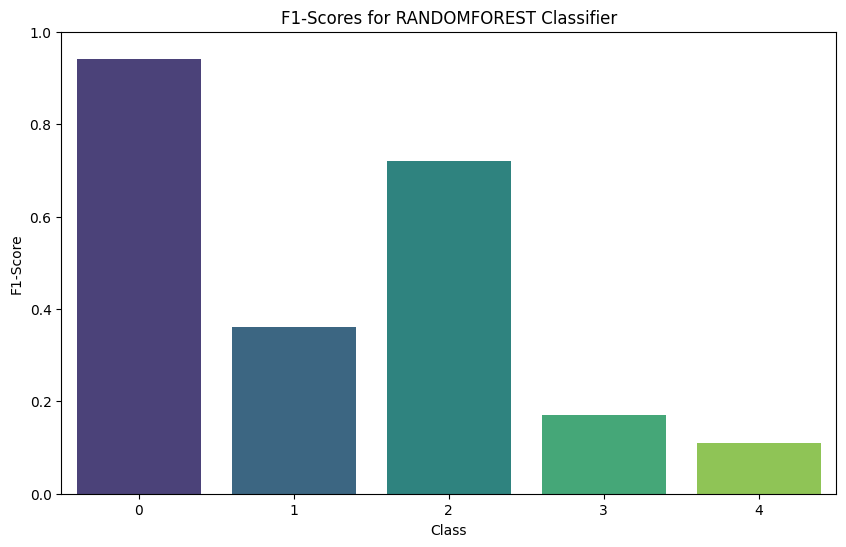


Plotting Normalized Heatmap for SVM...


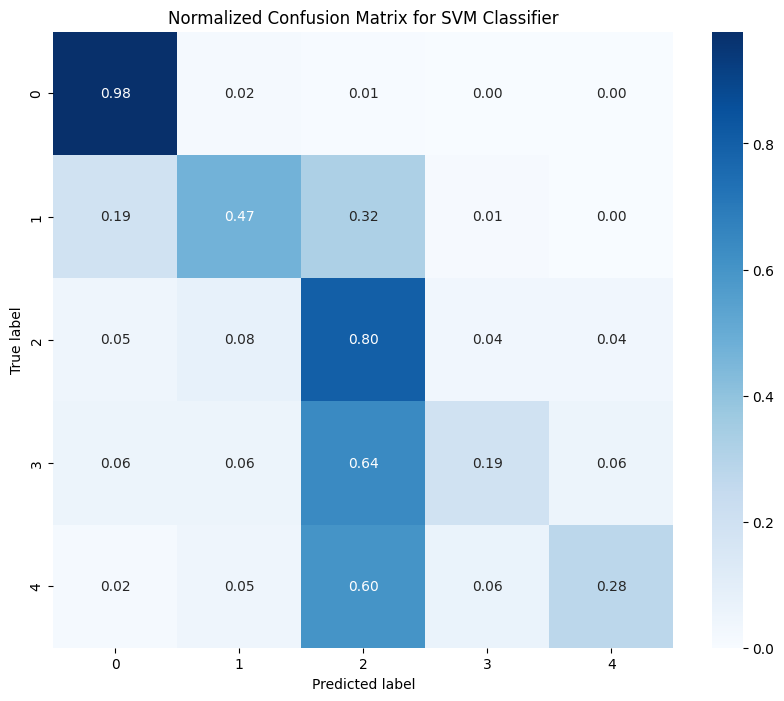

Plotting F1-Score Bar Chart for SVM...


d:\GitHub\final\scripts\visualize.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plt.ylim(0, 1.0)


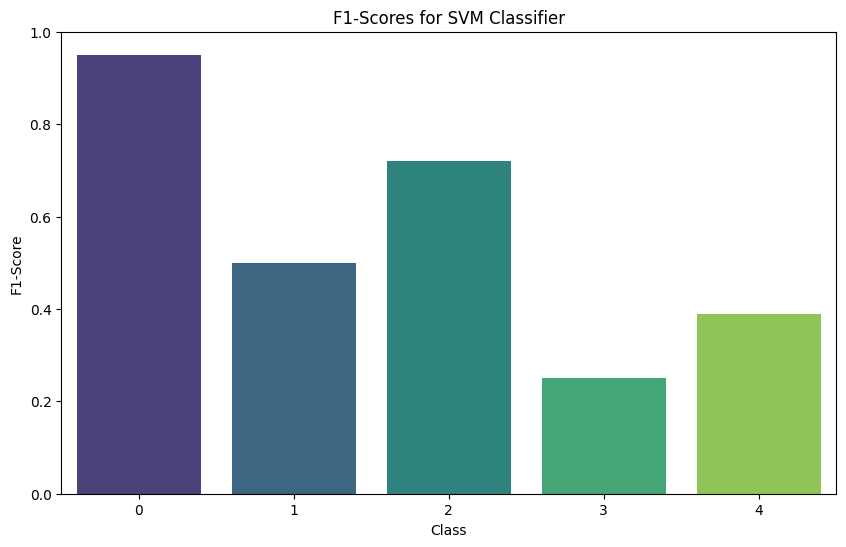


Plotting Normalized Heatmap for KNN...


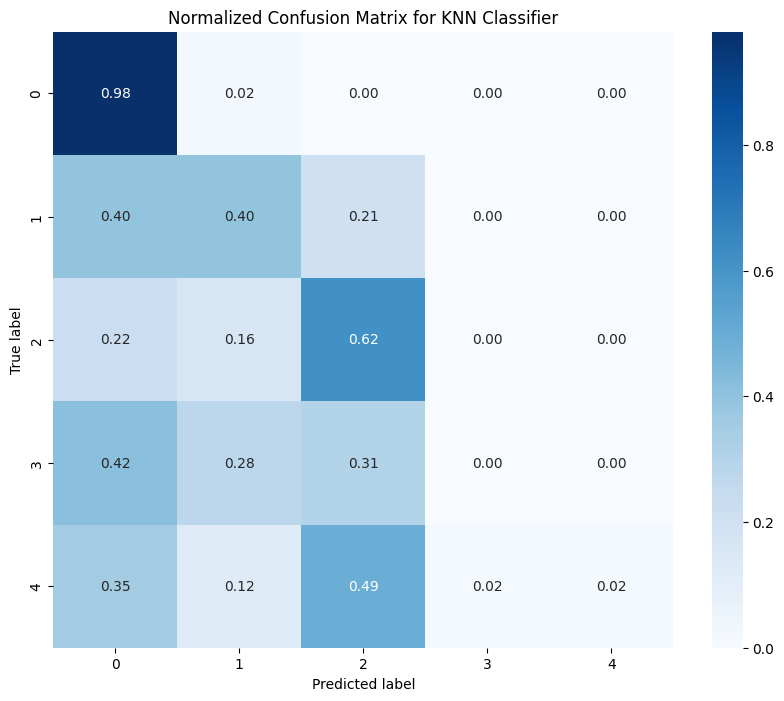

Plotting F1-Score Bar Chart for KNN...


d:\GitHub\final\scripts\visualize.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plt.ylim(0, 1.0)


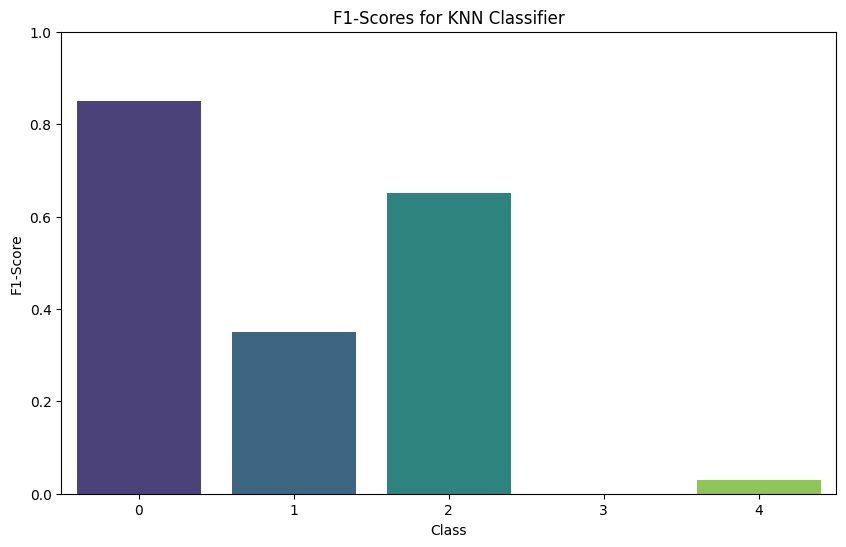


Plotting Normalized Heatmap for VOTINGCLASSIFIER...


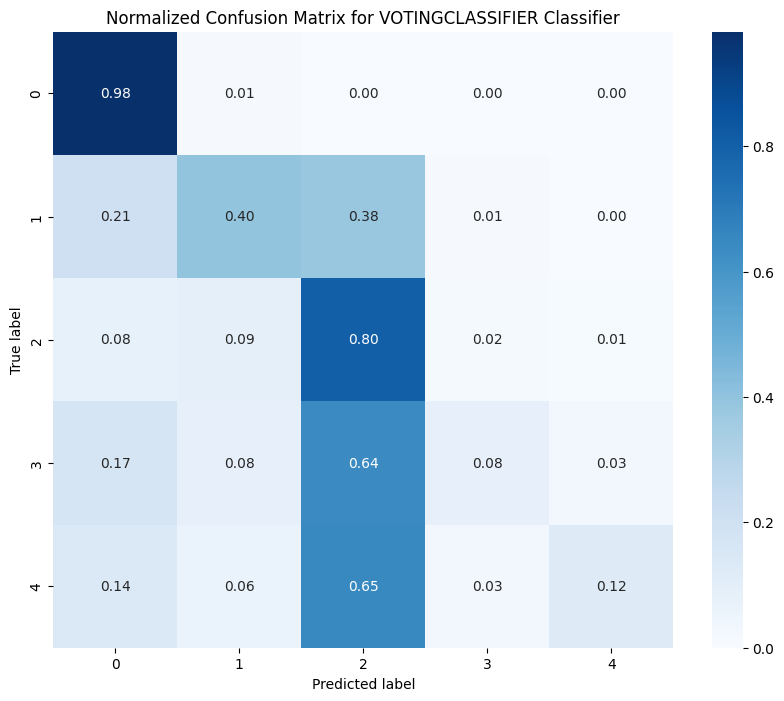

Plotting F1-Score Bar Chart for VOTINGCLASSIFIER...


d:\GitHub\final\scripts\visualize.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plt.ylim(0, 1.0)


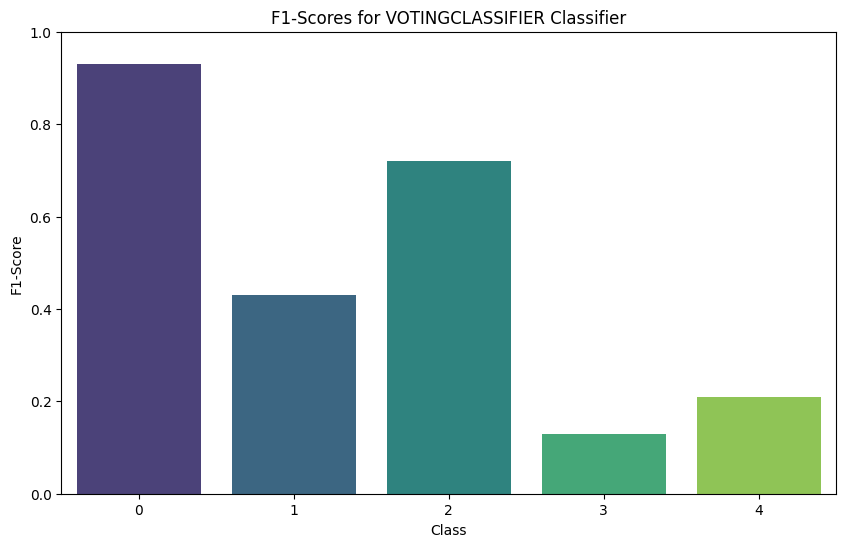


Visualization and evaluation of existing models complete.


In [ ]:
# Cell 2: Visualization of Existing Models (Run this after Cell 1 is done)

import os
import re
import numpy as np
import joblib
from sklearn.metrics import confusion_matrix
# This cell assumes you have already run Cell 1 to define the visualization functions.

print("\nStarting visualization of existing models and reports...")

outputs_path = "../outputs"
class_names = ['0', '1', '2', '3', '4']

classifiers_to_visualize = ["randomforest", "svm", "knn", "votingclassifier"]

for classifier in classifiers_to_visualize:
    report_path = os.path.join(outputs_path, f"{classifier}_report.txt")
    
    try:
        with open(report_path, 'r') as f:
            report_content = f.read()

        matrix_start_index = report_content.find("Confusion Matrix:")
        if matrix_start_index == -1:
            print(f"Error: 'Confusion Matrix:' not found in {report_path}.")
            continue
            
        matrix_data_raw = report_content[matrix_start_index:].split("Confusion Matrix:")[1]
        numbers = re.findall(r'\d+', matrix_data_raw)
        cm = np.array(numbers, dtype=int).reshape(5, 5)

        print(f"\nPlotting Normalized Heatmap for {classifier.upper()}...")
        plot_normalized_confusion_matrix(cm, class_names, f"Normalized Confusion Matrix for {classifier.upper()} Classifier")
        
        print(f"Plotting F1-Score Bar Chart for {classifier.upper()}...")
        plot_f1_scores(report_content, class_names, f"F1-Scores for {classifier.upper()} Classifier")
        
    except FileNotFoundError:
        print(f"Error: Could not find report file at {report_path}. Please run the training cell first.")
    except Exception as e:
        print(f"An error occurred during visualization for {classifier}:", e)

print("\nVisualization and evaluation of existing models complete.")